In [1]:
from neo4j import GraphDatabase
import pandas as pd

URI = "neo4j://127.0.0.1:7687"
AUTH_USER = "neo4j"
AUTH_PASSWORD = "master2025"
DATABASE = "llmakg"

driver = GraphDatabase.driver(URI, auth=(AUTH_USER, AUTH_PASSWORD))

In [ ]:


COUNT_QUERY = """
RETURN
  count{ (:Document) }   AS documents,
  count{ (:Chunk) }      AS chunks,
  count{ (:__Entity__) } AS entities
"""

REL_COUNT_QUERY = """
MATCH ()-[r]->()
RETURN count(r) AS relationships
"""

with driver.session(database=DATABASE) as session:
    row = session.run(COUNT_QUERY).single()
    rel_row = session.run(REL_COUNT_QUERY).single()

stats_before = pd.DataFrame([{
    "stage": "before",
    "documents": row["documents"],
    "chunks": row["chunks"],
    "entities": row["entities"],
    "relationships": rel_row["relationships"],
}])

stats_before.to_csv("kg_stats_before.csv", index=False)
stats_before


Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownLabelWarning} {category: UNRECOGNIZED} {title: The provided label is not in the database.} {description: One of the labels in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing label name is: Document)} {position: line: 3, column: 12, offset: 19} for query: '\nRETURN\n  count{ (:Document) }   AS documents,\n  count{ (:Chunk) }      AS chunks,\n  count{ (:__Entity__) } AS entities\n'


,stage,documents,chunks,entities,relationships
0,before,0,243,1331,4472


In [9]:
with driver.session(database=DATABASE) as session:
    row = session.run(COUNT_QUERY).single()
    rel_row = session.run(REL_COUNT_QUERY).single()

stats_after = pd.DataFrame([{
    "stage": "after",
    "documents": row["documents"],
    "chunks": row["chunks"],
    "entities": row["entities"],
    "relationships": rel_row["relationships"],
}])
stats_after

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownLabelWarning} {category: UNRECOGNIZED} {title: The provided label is not in the database.} {description: One of the labels in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing label name is: Document)} {position: line: 3, column: 12, offset: 19} for query: '\nRETURN\n  count{ (:Document) }   AS documents,\n  count{ (:Chunk) }      AS chunks,\n  count{ (:__Entity__) } AS entities\n'


,stage,documents,chunks,entities,relationships
0,after,0,243,1236,4472


In [10]:
stats_before = pd.read_csv("kg_stats_before.csv")
stats_all = pd.concat([stats_before, stats_after], ignore_index=True)
stats_all


,stage,documents,chunks,entities,relationships
0,before,0,243,1331,4472
1,after,0,243,1236,4472


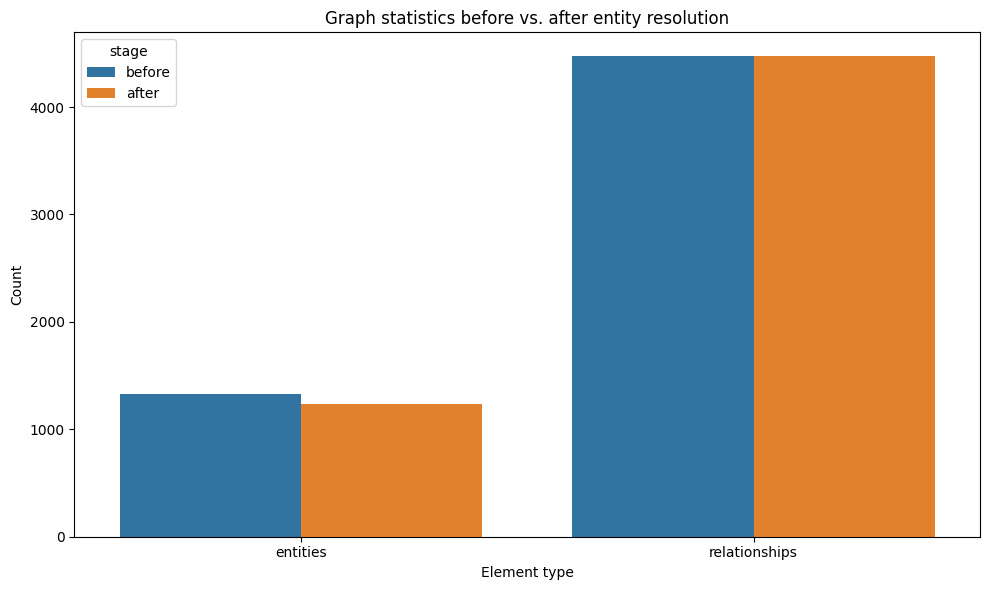

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_long = stats_all.melt(
    id_vars="stage",
    value_vars=["entities", "relationships"],
    var_name="type",
    value_name="count",
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=stats_long,
    x="type",
    y="count",
    hue="stage"
)
plt.title("Graph statistics before vs. after entity resolution")
plt.xlabel("Element type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Zweite DB

In [2]:
from concurrent.futures import ThreadPoolExecutor, as_completed

from tqdm import tqdm
from graphdatascience import GraphDataScience
from langchain_neo4j import Neo4jGraph

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

URI = "neo4j://127.0.0.1:7687"
AUTH_USER = "neo4j"
AUTH_PASSWORD = "master2025"
DATABASE = "llmakg"

MAX_WORKERS = 10

c:\Users\Nasiba\Documents\1 Master Data Science\Master Thesis\VS Code New\master_thesis-rag\.venv_Python11_New\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
graph = Neo4jGraph(
    url=URI,
    username=AUTH_USER,
    password=AUTH_PASSWORD,
    refresh_schema=False,
    database=DATABASE,
)

In [13]:
import pandas as pd

# Beispiel: alle Communities + Entity Counts
df_comm = pd.DataFrame(graph.query("""
MATCH (c:__Community__)
OPTIONAL MATCH (c)<-[:IN_COMMUNITY]-(e:__Entity__)
RETURN c.id AS id, c.level AS level, count(e) AS entity_count
ORDER BY level, entity_count DESC
"""))

df_comm.head()


,id,level,entity_count
0,0-327,0,84
1,0-990,0,83
2,0-26,0,53
3,0-433,0,50
4,0-47,0,40


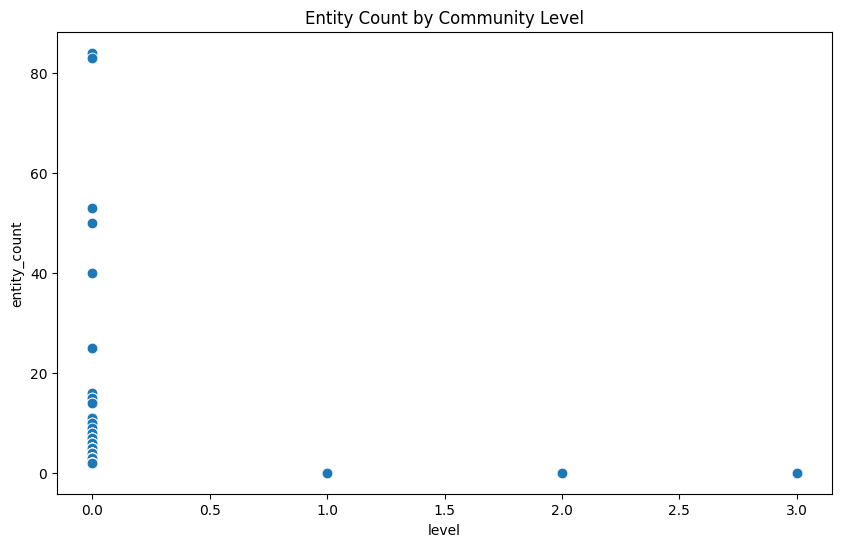

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_comm, x="level", y="entity_count", s=60)
plt.title("Entity Count by Community Level")
plt.show()


In [10]:
!pip install pyvis


   ---------------------------------------- 0.0/756.0 kB ? eta -:--:--
    --------------------------------------- 10.2/756.0 kB ? eta -:--:--
    --------------------------------------- 10.2/756.0 kB ? eta -:--:--
   --- ----------------------------------- 71.7/756.0 kB 787.7 kB/s eta 0:00:01
   ------------- -------------------------- 256.0/756.0 kB 1.7 MB/s eta 0:00:01
   ------------------- -------------------- 368.6/756.0 kB 2.1 MB/s eta 0:00:01
   ---------------------------- ----------- 532.5/756.0 kB 2.4 MB/s eta 0:00:01
   ------------------------------------ --- 696.3/756.0 kB 2.7 MB/s eta 0:00:01
   ---------------------------------------- 756.0/756.0 kB 2.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/47.1 kB ? eta -:--:--
   ---------------------------------------- 47.1/47.1 kB 2.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:

import numpy as np
import pandas as pd
community_size = graph.query(
    """
MATCH (c:__Community__)<-[:IN_COMMUNITY*]-(e:__Entity__)
WITH c, count(distinct e) AS entities
RETURN split(c.id, '-')[0] AS level, entities
"""
)
community_size_df = pd.DataFrame.from_records(community_size)
percentiles_data = []
for level in community_size_df["level"].unique():
    subset = community_size_df[community_size_df["level"] == level]["entities"]
    num_communities = len(subset)
    percentiles = np.percentile(subset, [25, 50, 75, 90, 99])
    percentiles_data.append(
        [
            level,
            num_communities,
            percentiles[0],
            percentiles[1],
            percentiles[2],
            percentiles[3],
            percentiles[4],
            max(subset)
        ]
    )

# Create a DataFrame with the percentiles
percentiles_df = pd.DataFrame(
    percentiles_data,
    columns=[
        "Level",
        "Number of communities",
        "25th Percentile",
        "50th Percentile",
        "75th Percentile",
        "90th Percentile",
        "99th Percentile",
        "Max"
    ],
)
percentiles_df

,Level,Number of communities,25th Percentile,50th Percentile,75th Percentile,90th Percentile,99th Percentile,Max
0,0,293,2.0,2.0,3.0,6.0,50.24,84
1,1,194,2.0,2.0,4.0,9.7,76.52,117
2,2,170,2.0,2.0,3.0,14.1,92.47,121
3,3,168,2.0,2.0,3.0,8.6,100.58,121


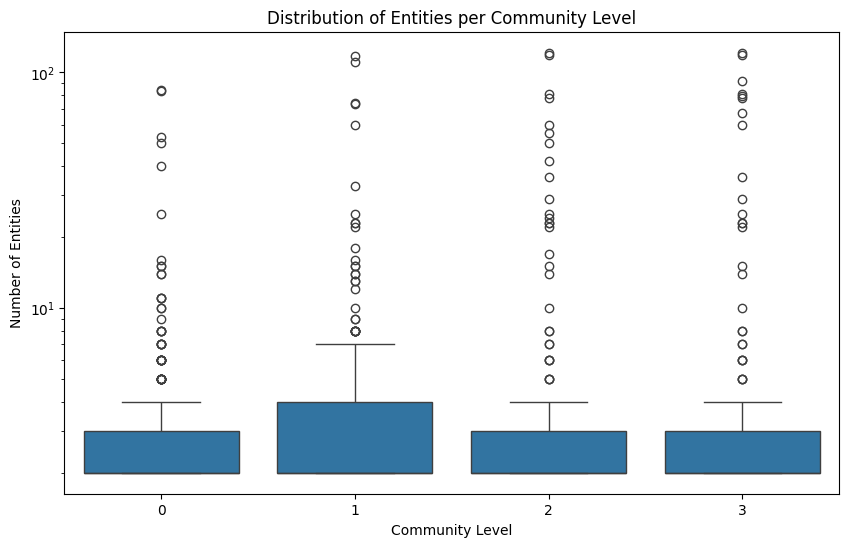

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(
    data=community_size_df,
    x="level",
    y="entities",
)
plt.title("Distribution of Entities per Community Level")
plt.xlabel("Community Level")
plt.ylabel("Number of Entities")
plt.yscale("log")   # optional, falls große Unterschiede bestehen
plt.show()


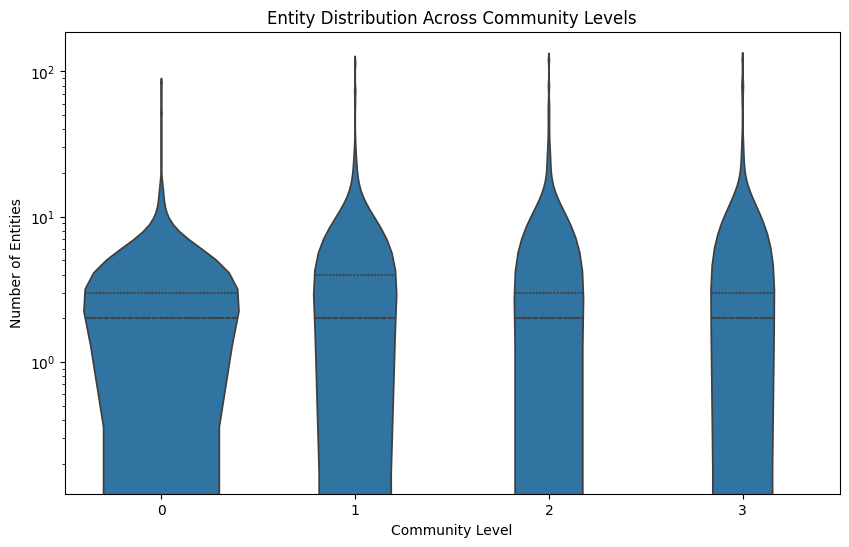

In [17]:
plt.figure(figsize=(10,6))
sns.violinplot(
    data=community_size_df,
    x="level",
    y="entities",
    inner="quartile"
)
plt.title("Entity Distribution Across Community Levels")
plt.xlabel("Community Level")
plt.ylabel("Number of Entities")
plt.yscale("log")  # optional
plt.show()


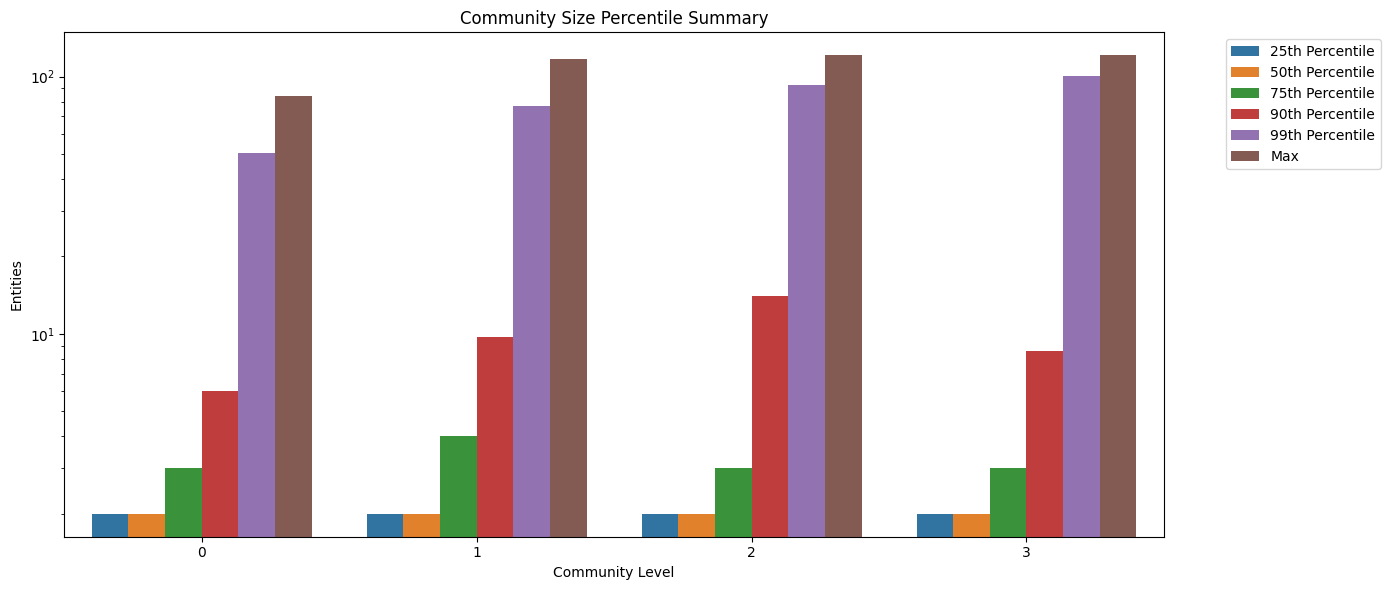

In [18]:
percentiles_plot = percentiles_df.melt(
    id_vars=["Level", "Number of communities"],
    value_vars=[
        "25th Percentile",
        "50th Percentile",
        "75th Percentile",
        "90th Percentile",
        "99th Percentile",
        "Max"
    ],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(14,6))
sns.barplot(
    data=percentiles_plot,
    x="Level",
    y="Value",
    hue="Metric"
)
plt.yscale("log")  # oft notwendig
plt.title("Community Size Percentile Summary")
plt.xlabel("Community Level")
plt.ylabel("Entities")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownPropertyKeyWarning} {category: UNRECOGNIZED} {title: The provided property key is not in the database} {description: One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing property name is: description)} {position: line: 11, column: 48, offset: 297} for query: "\nMATCH (c:`__Community__`)<-[:IN_COMMUNITY*]-(e:__Entity__)\nWHERE c.level IN [0,1,4]\nWITH c, collect(e) AS nodes\nWHERE size(nodes) > 1\nCALL apoc.path.subgraphAll(nodes[0], {\n    whitelistNodes:nodes\n})\nYIELD relationships\nRETURN c.id AS communityId, \n       [n in nodes | {\n            id: n.id,\n            description: n.description,\n            type: [el in labels(n) WHERE el <> '__Entity__'][0]\n       }] AS nodes,\n       [r in relationships | {\n            start: s

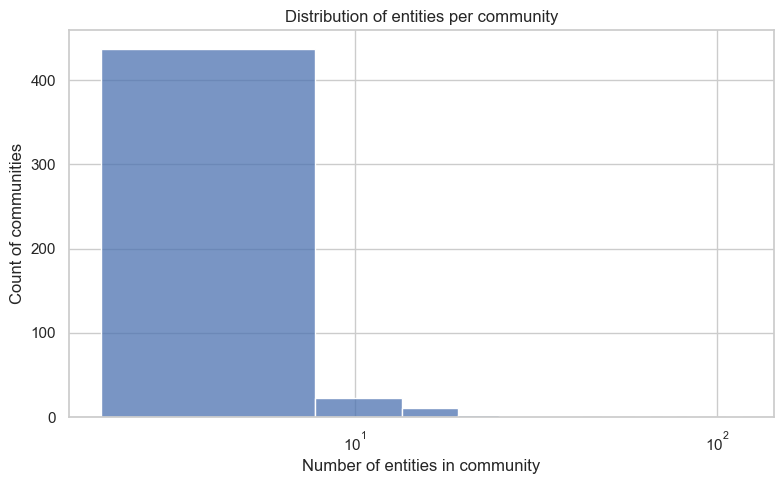

In [19]:
import pandas as pd

# 1) Neo4j-Query ausführen (wie bisher)
community_info = graph.query("""
MATCH (c:`__Community__`)<-[:IN_COMMUNITY*]-(e:__Entity__)
WHERE c.level IN [0,1,4]
WITH c, collect(e) AS nodes
WHERE size(nodes) > 1
CALL apoc.path.subgraphAll(nodes[0], {
    whitelistNodes:nodes
})
YIELD relationships
RETURN c.id AS communityId, 
       [n in nodes | {
            id: n.id,
            description: n.description,
            type: [el in labels(n) WHERE el <> '__Entity__'][0]
       }] AS nodes,
       [r in relationships | {
            start: startNode(r).id,
            type: type(r),
            end: endNode(r).id,
            description: r.description
       }] AS rels
""")

# 2) Aus community_info ein kompaktes DataFrame bauen
rows = []
for com in community_info:
    community_id = com["communityId"]
    level = str(community_id).split("-")[0]  # z.B. "0-12" -> "0"
    nodes = com["nodes"]
    rels = com["rels"]
    rows.append({
        "communityId": community_id,
        "level": level,
        "num_nodes": len(nodes),
        "num_rels": len(rels),
    })

community_df = pd.DataFrame(rows)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.histplot(
    data=community_df,
    x="num_nodes",
    bins=20
)
plt.xscale("log")  # optional, falls du einen starken Long-Tail hast
plt.title("Distribution of entities per community")
plt.xlabel("Number of entities in community")
plt.ylabel("Count of communities")
plt.tight_layout()
plt.show()



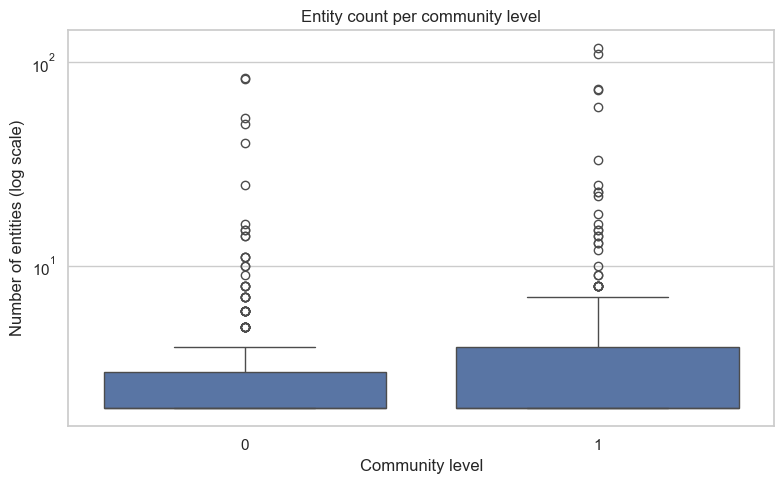

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=community_df,
    x="level",
    y="num_nodes"
)
plt.yscale("log")  # oft sinnvoll, falls manche Communities riesig sind
plt.title("Entity count per community level")
plt.xlabel("Community level")
plt.ylabel("Number of entities (log scale)")
plt.tight_layout()
plt.show()


In [28]:
import pandas as pd
from pyvis.network import Network

# --------------------------------------------------
# Parameter
# --------------------------------------------------
COMMUNITY_ID = "3-83"   # Deine Community-ID
MAX_DEPTH = 5           # Pfadtiefe (entspricht [*1..5])


# --------------------------------------------------
# 1) Knoten aus Neo4j holen (Community + alle Kinder)
#    -> Tiefe per f-String direkt in den Cypher-Text
# --------------------------------------------------
query_nodes = f"""
// Community + alle Knoten im Umkreis
MATCH (c:__Community__ {{id: $cid}})
MATCH path = (c)<-[*1..{MAX_DEPTH}]-(n)
WITH DISTINCT n
RETURN id(n) AS node_id,
       labels(n) AS labels,
       n.id AS business_id

UNION
// Community-Knoten selbst sicherstellen
MATCH (c:__Community__ {{id: $cid}})
RETURN id(c) AS node_id,
       labels(c) AS labels,
       c.id AS business_id
"""

df_nodes = pd.DataFrame(
    graph.query(query_nodes, params={"cid": COMMUNITY_ID})
)

print(f"Anzahl Knoten im Subgraph: {len(df_nodes)}")
display(df_nodes.head())


# --------------------------------------------------
# 2) Kanten aus Neo4j holen (nur innerhalb dieses Subgraphen)
# --------------------------------------------------
query_edges = f"""
MATCH (c:__Community__ {{id: $cid}})
MATCH path = (c)<-[rels*1..{MAX_DEPTH}]-(n)
UNWIND rels AS r
WITH DISTINCT r
RETURN id(startNode(r)) AS src,
       id(endNode(r))   AS dst,
       type(r)          AS rel_type
"""

df_edges = pd.DataFrame(
    graph.query(query_edges, params={"cid": COMMUNITY_ID})
)

print(f"Anzahl Kanten im Subgraph (vor Filter): {len(df_edges)}")

# Nur Kanten behalten, deren Endpunkte wir auch als Knoten haben
valid_ids = set(df_nodes["node_id"])
df_edges = df_edges[
    df_edges["src"].isin(valid_ids) & df_edges["dst"].isin(valid_ids)
]

print(f"Anzahl Kanten im Subgraph (nach Filter): {len(df_edges)}")
display(df_edges.head())


# --------------------------------------------------
# 3) PyVis-Graph aufbauen (hierarchisches Layout)
# --------------------------------------------------
net = Network(
    height="750px",
    width="100%",
    notebook=True,
    directed=True,   # gerichtet: gut für IN_COMMUNITY-Kanten
)

# Knoten hinzufügen
for _, row in df_nodes.iterrows():
    nid = row["node_id"]
    business_id = row["business_id"]
    labels = row["labels"] or []
    
    # Text, der im Graph angezeigt wird
    if business_id:
        label_text = str(business_id)
    else:
        label_text = ",".join(labels) if labels else str(nid)
    
    # einfache Optik je nach Label
    if "__Community__" in labels:
        shape = "box"
    elif "__Entity__" in labels:
        shape = "dot"
    else:
        shape = "ellipse"
    
    net.add_node(
        nid,
        label=label_text,
        shape=shape,
        title=f"Labels: {labels}"
    )

# Kanten hinzufügen
for _, row in df_edges.iterrows():
    net.add_edge(
        row["src"],
        row["dst"],
        title=row["rel_type"],
        arrows="to"
    )

# Hierarchisches Layout aktivieren
net.set_options("""
{
  "layout": {
    "hierarchical": {
      "enabled": true,
      "direction": "UD",
      "sortMethod": "hubsize",
      "nodeSpacing": 150,
      "levelSeparation": 150
    }
  },
  "physics": {
    "hierarchicalRepulsion": {
      "nodeDistance": 150
    },
    "stabilization": {
      "iterations": 200
    }
  }
}
""")


# --------------------------------------------------
# 4) Anzeige
# --------------------------------------------------
net.show(f"community_{COMMUNITY_ID.replace(':','_')}.html")


Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated function. ('id' has been replaced by 'elementId or consider using an application-generated id')} {position: line: 6, column: 8, offset: 127} for query: '\n// Community + alle Knoten im Umkreis\nMATCH (c:__Community__ {id: $cid})\nMATCH path = (c)<-[*1..5]-(n)\nWITH DISTINCT n\nRETURN id(n) AS node_id,\n       labels(n) AS labels,\n       n.id AS business_id\n\nUNION\n// Community-Knoten selbst sicherstellen\nMATCH (c:__Community__ {id: $cid})\nRETURN id(c) AS node_id,\n       labels(c) AS labels,\n       c.id AS business_id\n'
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be 

Anzahl Knoten im Subgraph: 185


,node_id,labels,business_id
0,1779,[__Community__],2-16
1,2036,[__Community__],2-123
2,1778,[__Community__],1-276
3,1818,[__Community__],1-85
4,1874,[__Community__],1-257


Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated function. ('id' has been replaced by 'elementId or consider using an application-generated id')} {position: line: 6, column: 8, offset: 110} for query: '\nMATCH (c:__Community__ {id: $cid})\nMATCH path = (c)<-[rels*1..5]-(n)\nUNWIND rels AS r\nWITH DISTINCT r\nRETURN id(startNode(r)) AS src,\n       id(endNode(r))   AS dst,\n       type(r)          AS rel_type\n'
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated function. ('id' has been replaced by 'elementId or consider using an application-generated id')}

Anzahl Kanten im Subgraph (vor Filter): 426
Anzahl Kanten im Subgraph (nach Filter): 426


,src,dst,rel_type
0,1779,1780,IN_COMMUNITY
1,1778,1779,IN_COMMUNITY
2,368,1778,IN_COMMUNITY
3,270,368,IN_COMMUNITY
4,2,270,MENTIONS


community_3-83.html
